# Baseline Defender Models

## Importing libraries

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score

print("Libraries imported successfully!")

Libraries imported successfully!


## Loading data

In [3]:
df = pd.read_csv('../data/featured_transactions_v1.csv')

print(f"Dataset shape: {df.shape}")
print(f"Fraud rate: {df['is_fraud'].mean()*100:.2f}%")
df.head()

Dataset shape: (205930, 11)
Fraud rate: 1.96%


,Transaction_id,Timestamp,user_id,is_fraud,fraud_campaign,amount_zscore,transactions_last_1h,transactions_last_24h,time_since_last_txn,is_new_category,is_foreign
0,83278,2025-01-01 07:47:06,USER_C_1001,0,NaN,0.000000,0,0,0.0,1,0
1,106255,2025-01-01 07:47:17,USER_C_1001,0,NaN,0.000000,1,1,11.0,1,0
2,20501,2025-01-01 08:57:34,USER_C_1001,0,NaN,1.509677,0,2,4217.0,0,0
3,102698,2025-01-01 09:27:02,USER_C_1001,0,NaN,1.018567,1,3,1768.0,0,0
4,144902,2025-01-01 10:01:35,USER_C_1001,0,NaN,0.056693,1,4,2073.0,0,0


## Time-based train/test data split

In [4]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
cutoff = df['Timestamp'].quantile(0.8)
train_df = df[df['Timestamp'] <= cutoff]
test_df = df[df['Timestamp'] > cutoff]

feature_cols = ['amount_zscore', 'transactions_last_1h', 'transactions_last_24h', 'time_since_last_txn', 'is_new_category', 'is_foreign']
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df['is_fraud']
y_test = test_df['is_fraud']

print(f"Training data shape: {train_df.shape}, Fraud rate: {train_df['is_fraud'].mean()*100:.2f}%")
print(f"Testing data shape: {test_df.shape}, Fraud rate: {test_df['is_fraud'].mean()*100:.2f}%")

Training data shape: (164744, 11), Fraud rate: 1.97%
Testing data shape: (41186, 11), Fraud rate: 1.93%


## Feature scaling

In [5]:
# Scale features to same range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")

Features scaled successfully!


## Train models

### Naive Models

In [6]:
# Train models
# Model 1 : Logistic Regression
print("="*70)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*70)

lr_naive = LogisticRegression(max_iter=1000)
lr_naive.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

# Model 2 : Random Forest
print("="*70)
print("MODEL 2: RANDOM FOREST")
print("="*70)

# n_estimators = number of trees
# max_depth = how deep each tree can go
rf_naive = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)
rf_naive.fit(X_train_scaled, y_train)

print("Random Forest trained successfully!")

# Model 3 : XGBoost
print("="*70)
print("MODEL 3: XGBOOST")
print("="*70)

xgb_naive = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_naive.fit(X_train_scaled, y_train)

print("XGBoost trained successfully!")

MODEL 1: LOGISTIC REGRESSION
Logistic Regression trained successfully!
MODEL 2: RANDOM FOREST
Random Forest trained successfully!
MODEL 3: XGBOOST
XGBoost trained successfully!


### Balanced Models

In [7]:
# Class weight for XGBoost
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"XGBoost scale_pos_weight: {scale_pos_weight:.2f}")

# Train models
# Model 1 : Logistic Regression
print("="*70)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*70)

lr_model = LogisticRegression(class_weight="balanced", max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

# Model 2 : Random Forest
print("="*70)
print("MODEL 2: RANDOM FOREST")
print("="*70)

# n_estimators = number of trees
# max_depth = how deep each tree can go
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)
rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained successfully!")

# Model 3 : XGBoost
print("="*70)
print("MODEL 3: XGBOOST")
print("="*70)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)

print("XGBoost trained successfully!")

XGBoost scale_pos_weight: 49.77
MODEL 1: LOGISTIC REGRESSION
Logistic Regression trained successfully!
MODEL 2: RANDOM FOREST
Random Forest trained successfully!
MODEL 3: XGBOOST
XGBoost trained successfully!


### Model evaluation function

In [8]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """
    Evaluate a model on both training and test data. 
    Returns a dictionary of test metrics for comparison.
    """
    # Training performance
    y_train_pred = model.predict(X_train)
    train_f1 = f1_score(y_train, y_train_pred)

    # Test performance
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    auc = roc_auc_score(y_test, y_test_proba)

    print(f"Train F1: {train_f1:.4f} | Test F1: {f1:.4f}")

    print(f"\n{name}")
    print("-"*50)
    print(f"Precision:  {precision:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(f"F1 Score:   {f1:.4f}")
    print(f"ROC-AUC:    {auc:.4f}")
    print("-"*50)

    return {'name': name, 'precision': precision, 'recall': recall, 'f1': f1, 'auc': auc}

print("\n=== NAIVE MODELS (No Class Balancing) ===")
evaluate_model("Logistic Regression (Naive)", lr_naive, X_train_scaled, y_train, X_test_scaled, y_test)
evaluate_model("Random Forest (Naive)", rf_naive, X_train_scaled, y_train, X_test_scaled, y_test)
evaluate_model("XGBoost (Naive)", xgb_naive, X_train_scaled, y_train, X_test_scaled, y_test)

print("\n=== BALANCED MODELS ===")
evaluate_model("Logistic Regression (Balanced)", lr_model, X_train_scaled, y_train, X_test_scaled, y_test)
evaluate_model("Random Forest (Balanced)", rf_model, X_train_scaled, y_train, X_test_scaled, y_test)
evaluate_model("XGBoost (Balanced)", xgb_model, X_train_scaled, y_train, X_test_scaled, y_test)


=== NAIVE MODELS (No Class Balancing) ===
Train F1: 0.4084 | Test F1: 0.3219

Logistic Regression (Naive)
--------------------------------------------------
Precision:  0.8154
Recall:     0.2005
F1 Score:   0.3219
ROC-AUC:    0.7955
--------------------------------------------------
Train F1: 0.7563 | Test F1: 0.6955

Random Forest (Naive)
--------------------------------------------------
Precision:  0.9861
Recall:     0.5372
F1 Score:   0.6955
ROC-AUC:    0.9247
--------------------------------------------------
Train F1: 0.7516 | Test F1: 0.6849

XGBoost (Naive)
--------------------------------------------------
Precision:  0.9487
Recall:     0.5359
F1 Score:   0.6849
ROC-AUC:    0.9285
--------------------------------------------------

=== BALANCED MODELS ===
Train F1: 0.2131 | Test F1: 0.1893

Logistic Regression (Balanced)
--------------------------------------------------
Precision:  0.1130
Recall:     0.5826
F1 Score:   0.1893
ROC-AUC:    0.8415
------------------------------

{'name': 'XGBoost (Balanced)',
 'precision': 0.3159242191500256,
 'recall': 0.7780580075662042,
 'f1': 0.4493809176984705,
 'auc': 0.9274214543247523}

=== NAIVE MODELS ===


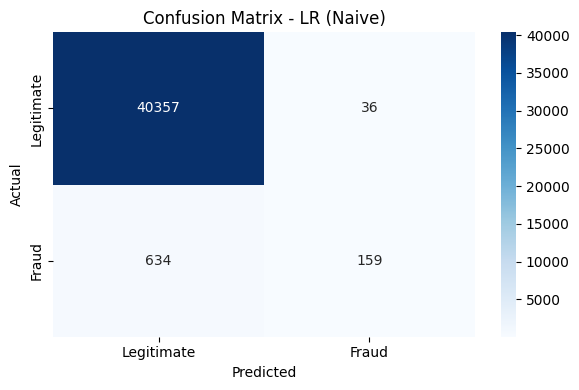

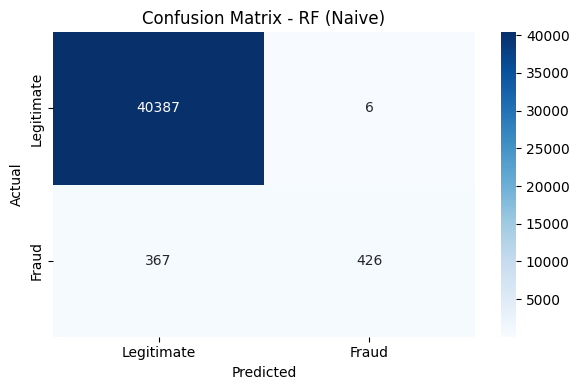

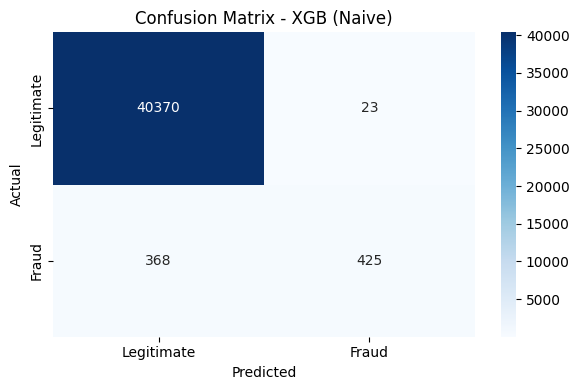

=== BALANCED MODELS ===


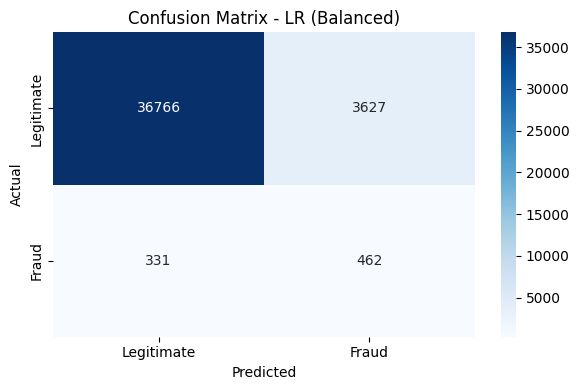

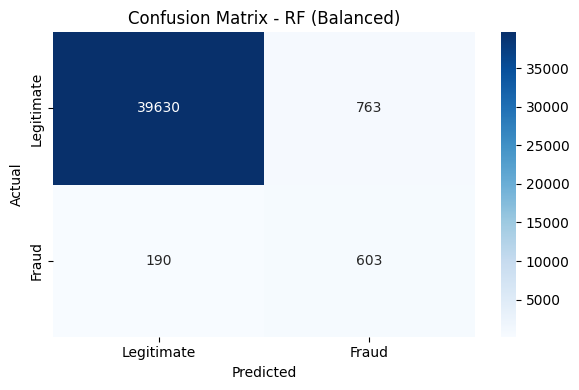

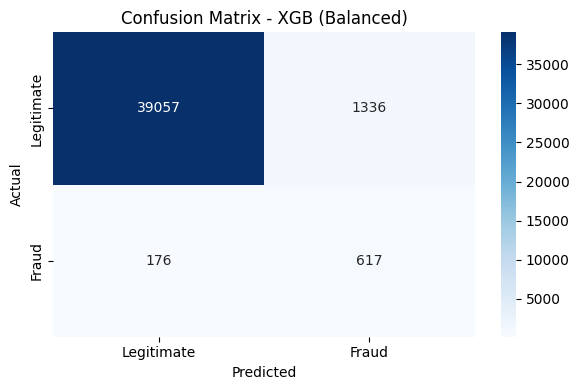

In [11]:
def plot_confusion_matrix(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])

    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

print("=== NAIVE MODELS ===")
plot_confusion_matrix("LR (Naive)", lr_naive, X_test_scaled, y_test)
plot_confusion_matrix("RF (Naive)", rf_naive, X_test_scaled, y_test)
plot_confusion_matrix("XGB (Naive)", xgb_naive, X_test_scaled, y_test)

print("=== BALANCED MODELS ===")
plot_confusion_matrix("LR (Balanced)", lr_model, X_test_scaled, y_test)
plot_confusion_matrix("RF (Balanced)", rf_model, X_test_scaled, y_test)
plot_confusion_matrix("XGB (Balanced)", xgb_model, X_test_scaled, y_test)

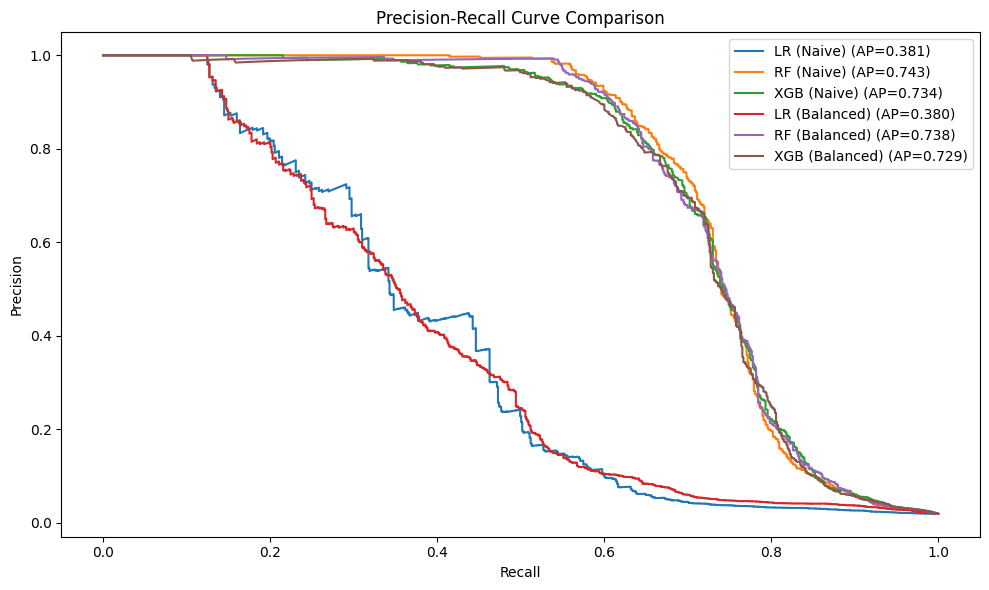

In [14]:
def plot_precision_recall_comparison(model, X_test, y_test):
    plt.figure(figsize=(10, 6))
    
    for name, model in models.items():
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        ap_score = average_precision_score(y_test, y_pred_proba)
        plt.plot(recall, precision, label=f'{name} (AP={ap_score:.3f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison')
    plt.legend()
    plt.tight_layout()
    plt.show()

models = {
    'LR (Naive)': lr_naive,
    'RF (Naive)': rf_naive,
    'XGB (Naive)': xgb_naive,
    'LR (Balanced)': lr_model,
    'RF (Balanced)': rf_model,
    'XGB (Balanced)': xgb_model
}

plot_precision_recall_comparison(models, X_test_scaled, y_test)

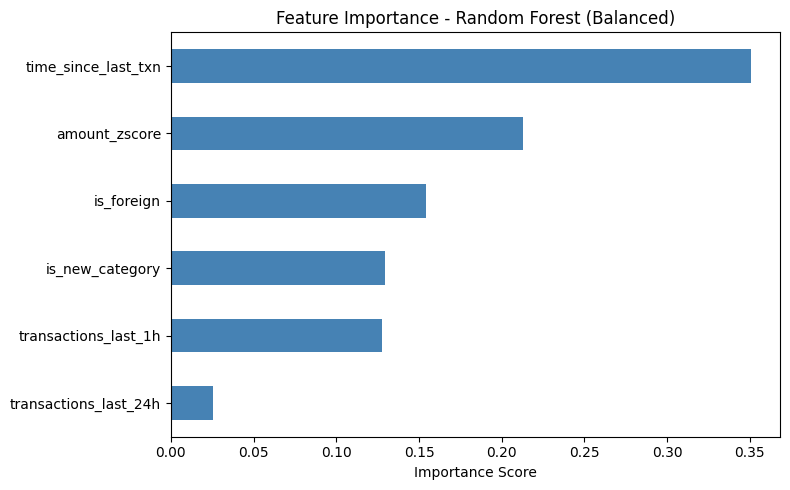

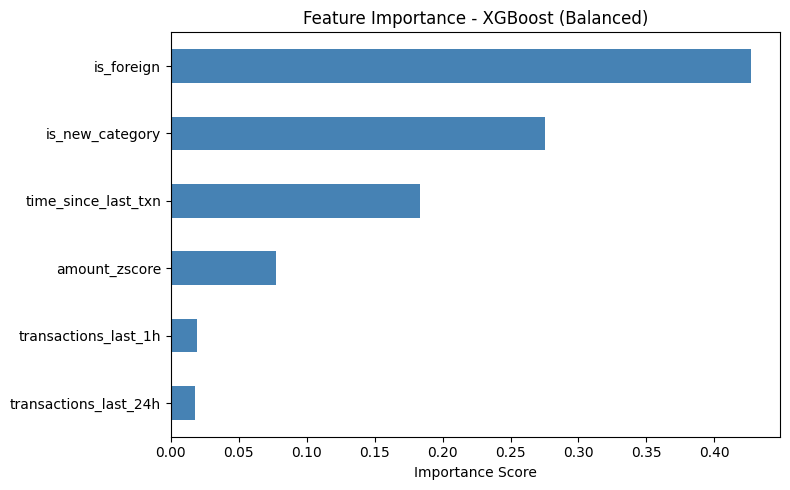

In [15]:
def plot_feature_importance(name, model, feature_cols):
    importance = model.feature_importances_
    feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=True)
    
    plt.figure(figsize=(8, 5))
    feat_imp.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importance - {name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

# Only RF and XGBoost have feature_importances_
plot_feature_importance("Random Forest (Balanced)", rf_model, feature_cols)
plot_feature_importance("XGBoost (Balanced)", xgb_model, feature_cols)

## Save results

In [16]:
results = []
results.append(evaluate_model("LR (Naive)", lr_naive, X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model("RF (Naive)", rf_naive, X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model("XGB (Naive)", xgb_naive, X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model("LR (Balanced)", lr_model, X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model("RF (Balanced)", rf_model, X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model("XGB (Balanced)", xgb_model, X_train_scaled, y_train, X_test_scaled, y_test))

results_df = pd.DataFrame(results).set_index('name')
results_df = results_df.round(4)
print("\n=== MODEL COMPARISON TABLE ===")
print(results_df.to_string())
results_df.to_csv('../results/baseline_results.csv')
print("\nResults saved to results/baseline_results.csv")

Train F1: 0.4084 | Test F1: 0.3219

LR (Naive)
--------------------------------------------------
Precision:  0.8154
Recall:     0.2005
F1 Score:   0.3219
ROC-AUC:    0.7955
--------------------------------------------------
Train F1: 0.7563 | Test F1: 0.6955

RF (Naive)
--------------------------------------------------
Precision:  0.9861
Recall:     0.5372
F1 Score:   0.6955
ROC-AUC:    0.9247
--------------------------------------------------
Train F1: 0.7516 | Test F1: 0.6849

XGB (Naive)
--------------------------------------------------
Precision:  0.9487
Recall:     0.5359
F1 Score:   0.6849
ROC-AUC:    0.9285
--------------------------------------------------
Train F1: 0.2131 | Test F1: 0.1893

LR (Balanced)
--------------------------------------------------
Precision:  0.1130
Recall:     0.5826
F1 Score:   0.1893
ROC-AUC:    0.8415
--------------------------------------------------
Train F1: 0.5194 | Test F1: 0.5586

RF (Balanced)
----------------------------------------------

In [17]:
import joblib
import os

os.makedirs('../results/models', exist_ok=True)

# Save balanced models (primary defenders)
joblib.dump(lr_model, '../results/models/lr_balanced.pkl')
joblib.dump(rf_model, '../results/models/rf_balanced.pkl')
joblib.dump(xgb_model, '../results/models/xgb_balanced.pkl')

# Save naive models (for comparison)
joblib.dump(lr_naive, '../results/models/lr_naive.pkl')
joblib.dump(rf_naive, '../results/models/rf_naive.pkl')
joblib.dump(xgb_naive, '../results/models/xgb_naive.pkl')

# Save scaler
joblib.dump(scaler, '../results/models/scaler.pkl')

print("All models saved successfully!")
print("Saved to results/models/:")
for f in os.listdir('../results/models'):
    print(f"  - {f}")

All models saved successfully!
Saved to results/models/:
  - lr_balanced.pkl
  - lr_naive.pkl
  - rf_balanced.pkl
  - rf_naive.pkl
  - scaler.pkl
  - xgb_balanced.pkl
  - xgb_naive.pkl
